# Task 1 · Step 3 — Length confounding

**Objective.** For a prompt $x$ with preferred / rejected responses $(y^+, y^-)$, a trainable policy $\pi_\theta$ and the frozen reference $\pi_{\text{ref}}$,
$$\mathcal{L}_{\text{DPO}}(\theta)=-\mathbb{E}\Big[\log\sigma\Big(\beta\Big[\log\tfrac{\pi_\theta(y^+|x)}{\pi_{\text{ref}}(y^+|x)}-\log\tfrac{\pi_\theta(y^-|x)}{\pi_{\text{ref}}(y^-|x)}\Big]\Big)\Big],$$
with sequence log-probabilities summed over response tokens only (teacher forcing).

**Setting.** Policy = `Qwen/Qwen2.5-1.5B-Instruct` + a fresh LoRA adapter (r = 8, α = 16, dropout 0.05, `q_proj`/`v_proj`); reference = the same network with the adapter disabled. AdamW, lr 2e-5, 2 pairs × 8 accumulation steps = 16 pairs per optimizer step, gradient clipping 1.0, seed 6304, fp16 on a T4.

**Sequence-length policy (TA clarification, 3 Oct).** Some prompt + response pairs exceed the 768-token limit. For every DPO training *and* evaluation run the prompt is kept intact and an over-length response is right-truncated (no EOS is appended to a cut response); pairs whose prompt leaves fewer than 64 response tokens are dropped. The same rule is used for all conditions.

**Protocol.** One additional DPO model is trained from the original initialisation on the supplied length-balanced subset (500 pairs from each stratum: preferred response clearly longer / length matched / rejected response clearly longer; strata defined by the course). Standard and length-balanced DPO are evaluated on the supplied length-stratified held-out set (82 pairs per stratum before the overlength filter), and all three policies (SFT, standard, length-balanced) answer the ten common word-limit prompts (greedy decoding, plus 8 sampled answers per prompt).

**Research questions.** (RQ2) How much of the observed length behaviour can be explained by the preference data itself; does balancing the strata change which examples are learned well or how long the model responds? (RQ3) Cases where the aligned policy has a stronger preference/reward signal but a worse response.


In [1]:
%matplotlib inline
import os, sys, json, re
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "configs").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yaml
from IPython.display import display, Markdown, HTML, Image
from common.nb_helpers import (style, load, jl, exists, pending, run, side_by_side, ci_text,
                               bootstrap_mean_diff, smooth, full_windows, PALETTE, SEQ, RES, FIG)
from common.metrics import length_stats, wilson_interval
from common.data import load_yaml
style()
print("repo root:", ROOT)

repo root: C:\Users\moize\OneDrive - Higher Education Commission\Desktop\Academics\ATML\PA2


## Run this step (optional)
The results below come from the Kaggle run of the script pipeline (`kaggle_runner.ipynb`). Set `FORCE_RUN = True`
to re-run the step's scripts from here (needs a CUDA GPU and the downloaded course assets).


In [2]:
FORCE_RUN = False
if FORCE_RUN:
    run('python -m task1_dpo.analyze_length --config configs/dpo.yaml --skip-train')
else:
    print('Using saved results under results/ (FORCE_RUN = False).')

Using saved results under results/ (FORCE_RUN = False).


## 1. Length structure of the two training sets (a property of the data)

In [3]:
pre = load("task1_dpo/dpo_preprocessing_report.json")["files"]
rows = []
for key, lab in [("dpo_standard_train", "standard train"), ("dpo_length_train", "length-balanced train"), ("dpo_length_eval", "length-stratified eval")]:
    f = pre[key]
    rows.append({"set": lab, "pairs": f["total"]["pairs"], "kept": f["total"].get("kept"),
                 "mean tokens(chosen) − tokens(rejected)": f["chosen_minus_rejected_tokens_full"]["mean"],
                 "share chosen longer": f["chosen_minus_rejected_tokens_full"]["frac_chosen_longer"]})
display(pd.DataFrame(rows).set_index("set").round(3))
strat = []
for key in ["dpo_length_train", "dpo_length_eval"]:
    for s, st in pre[key]["per_stratum"].items():
        strat.append({"set": key, "stratum": s, "pairs": st["pairs"], "dropped": st.get("dropped_here", 0),
                      "kept": st.get("kept", 0), "response truncated": st.get("either_truncated_here", 0)})
pd.DataFrame(strat).set_index(["set", "stratum"])

,pairs,kept,mean tokens(chosen) − tokens(rejected),share chosen longer
set,,,,
standard train,1500,1443,45.929,0.571
length-balanced train,1500,1432,4.865,0.492
length-stratified eval,246,235,2.145,0.477


pairs  dropped  kept  response truncated
set              stratum                                                   
dpo_length_train rejected_longer     500       22   478                  12
                 preferred_longer    500       25   475                  13
                 length_matched      500       21   479                   8
dpo_length_eval  rejected_longer      82        3    79                   3
                 preferred_longer     82        6    76                   2
                 length_matched       82        2    80                   0

## 2. Training: standard vs length-balanced

(curves omit 1 partial accumulation window(s): step 91 = 4 pairs)
(curves omit 1 partial accumulation window(s): step 90 = 8 pairs)


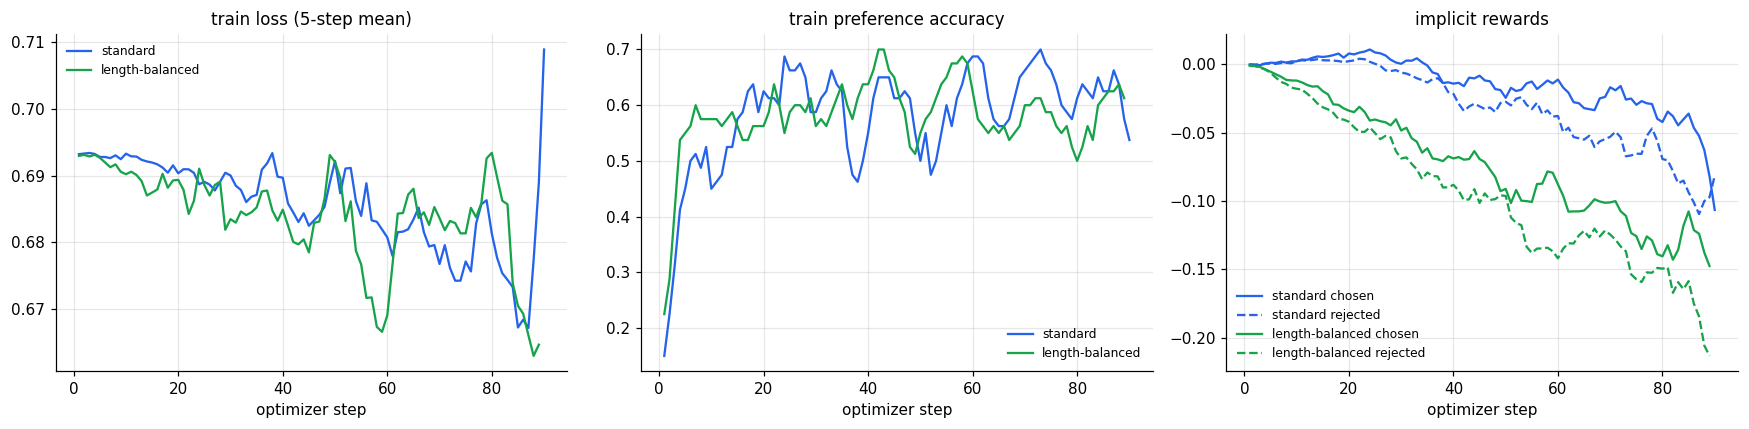

In [4]:
Ls = {"standard": full_windows(pd.DataFrame(jl("task1_dpo/dpo_train_standard.jsonl"))),
      "length-balanced": full_windows(pd.DataFrame(jl("task1_dpo/dpo_train_length_balanced.jsonl")))}
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for (n, L), c in zip(Ls.items(), ["#2563EB", "#16A34A"]):
    ax[0].plot(L.step, smooth(L.loss), color=c, label=n)
    ax[1].plot(L.step, smooth(L.preference_accuracy), color=c, label=n)
    ax[2].plot(L.step, smooth(L.implicit_chosen_reward_mean), color=c, label=f"{n} chosen")
    ax[2].plot(L.step, smooth(L.implicit_rejected_reward_mean), color=c, ls="--", label=f"{n} rejected")
for a, t in zip(ax, ["train loss (5-step mean)", "train preference accuracy", "implicit rewards"]):
    a.set_title(t); a.set_xlabel("optimizer step"); a.legend(fontsize=8)
fig.tight_layout(); plt.show()

## 3. Held-out accuracy by length stratum
Strata are the course labels. 95% Wilson intervals. Margins in nats (unscaled log-ratio difference).


In [5]:
LA = load("task1_dpo/dpo_length_analysis.json")
STRATA = ["preferred_longer", "length_matched", "rejected_longer"]
rows = []
for s in STRATA:
    for mdl in ["standard", "length_balanced"]:
        st = LA[mdl]["stratified"][s]
        rows.append({"stratum": s, "model": mdl, "pairs": st["total_pairs"], "accuracy": ci_text(st["accuracy"], st["accuracy_ci95"]),
                     "mean margin": st["mean_margin"], "median margin": st["median_margin"], "mean loss": st["mean_dpo_loss"],
                     "pairs w/ truncated response": st["pairs_with_truncated_response"],
                     "mean tokens chosen / rejected": f"{st['mean_chosen_tokens']:.0f} / {st['mean_rejected_tokens']:.0f}"})
pd.DataFrame(rows).set_index(["stratum", "model"]).round(3)

pairs        accuracy  mean margin  median margin  mean loss  pairs w/ truncated response mean tokens chosen / rejected
stratum          model                                                                                                                                   
preferred_longer standard            76  44.7% [34, 56]       -0.084         -0.153      0.700                            2                     223 / 106
                 length_balanced     76  43.4% [33, 55]       -0.489         -0.383      0.722                            2                     223 / 106
length_matched   standard            80  58.8% [48, 69]        0.200          0.118      0.685                            0                     123 / 123
                 length_balanced     80  61.3% [50, 71]        0.343          0.181      0.678                            0                     123 / 123
rejected_longer  standard            79  65.8% [55, 75]        0.657          0.596      0.664                            3                     102 / 208
                 length_balanced     79  78.5% [68, 86]        1.430          1.393      0.630                            3                     102 / 208

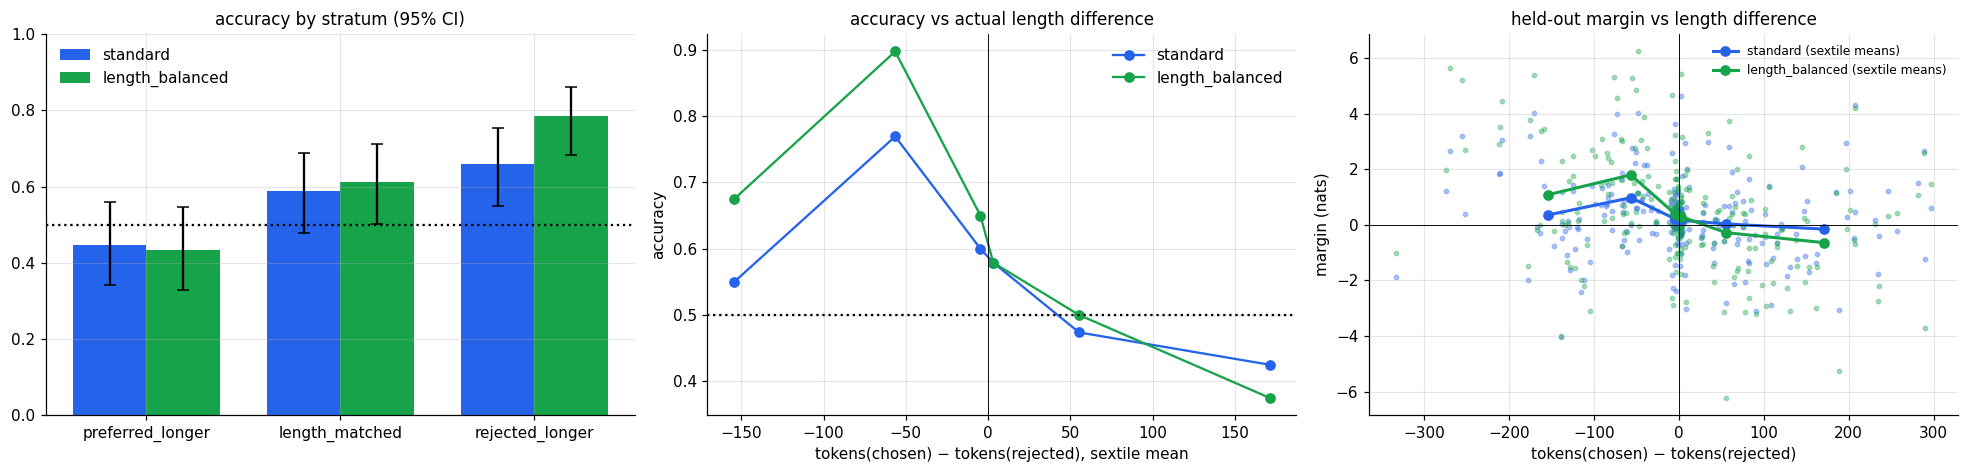

standard         accuracy when chosen is longer 0.473 (n=112), when chosen is shorter 0.639 (n=119); corr(log-ratio, length): chosen -0.21, rejected -0.24
length_balanced  accuracy when chosen is longer 0.464 (n=112), when chosen is shorter 0.739 (n=119); corr(log-ratio, length): chosen -0.36, rejected -0.35


In [6]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4.4))
for j, (mdl, c) in enumerate([("standard", "#2563EB"), ("length_balanced", "#16A34A")]):
    st = LA[mdl]["stratified"]
    acc = np.array([st[s]["accuracy"] for s in STRATA]); ci = np.array([st[s]["accuracy_ci95"] for s in STRATA])
    ax[0].bar(np.arange(3) + (j - 0.5) * 0.38, acc, 0.38, yerr=[acc - ci[:, 0], ci[:, 1] - acc], capsize=4, color=c, label=mdl)
    pp = pd.DataFrame(LA[mdl]["per_pair"]); pp["d"] = pp.chosen_tokens_full - pp.rejected_tokens_full
    bins = pd.qcut(pp.d, 6, duplicates="drop")
    g = pp.groupby(bins, observed=True).agg(d=("d", "mean"), acc=("margin", lambda m: (m > 0).mean()), margin=("margin", "mean"))
    ax[1].plot(g.d, g.acc, "o-", color=c, label=mdl); ax[2].scatter(pp.d, pp.margin, s=8, alpha=0.35, color=c)
    ax[2].plot(g.d, g.margin, "o-", color=c, lw=2, label=f"{mdl} (sextile means)")
ax[0].set_xticks(range(3)); ax[0].set_xticklabels(STRATA); ax[0].axhline(0.5, color="k", ls=":"); ax[0].set_ylim(0, 1)
ax[0].set_title("accuracy by stratum (95% CI)"); ax[0].legend()
ax[1].axhline(0.5, color="k", ls=":"); ax[1].axvline(0, color="k", lw=0.6); ax[1].set_xlabel("tokens(chosen) − tokens(rejected), sextile mean")
ax[1].set_ylabel("accuracy"); ax[1].set_title("accuracy vs actual length difference"); ax[1].legend()
ax[2].axhline(0, color="k", lw=0.6); ax[2].axvline(0, color="k", lw=0.6); ax[2].set_xlabel("tokens(chosen) − tokens(rejected)")
ax[2].set_ylabel("margin (nats)"); ax[2].set_title("held-out margin vs length difference"); ax[2].legend(fontsize=8)
fig.tight_layout(); plt.show()
for mdl in ["standard", "length_balanced"]:
    pp = pd.DataFrame(LA[mdl]["per_pair"]); longer = pp.chosen_tokens_full > pp.rejected_tokens_full
    print(f"{mdl:16s} accuracy when chosen is longer {np.mean(pp.margin[longer] > 0):.3f} (n={longer.sum()}), "
          f"when chosen is shorter {np.mean(pp.margin[pp.chosen_tokens_full < pp.rejected_tokens_full] > 0):.3f} "
          f"(n={(pp.chosen_tokens_full < pp.rejected_tokens_full).sum()}); corr(log-ratio, length): "
          f"chosen {np.corrcoef(pp.logratio_chosen, pp.chosen_tokens_kept)[0,1]:+.2f}, rejected {np.corrcoef(pp.logratio_rejected, pp.rejected_tokens_kept)[0,1]:+.2f}")

## 4. Generated length on the held-out prompts (a property of the policy)

,length mean,std,median,IQR,EOS rate,RM,KL token
SFT,162.585,102.5560,222.5,206.00,0.55,1.2824,0.0000
standard DPO,158.835,102.0591,195.0,207.00,0.57,1.2987,0.0005
length-balanced DPO,162.770,101.4260,217.5,205.25,0.56,1.3698,0.0028


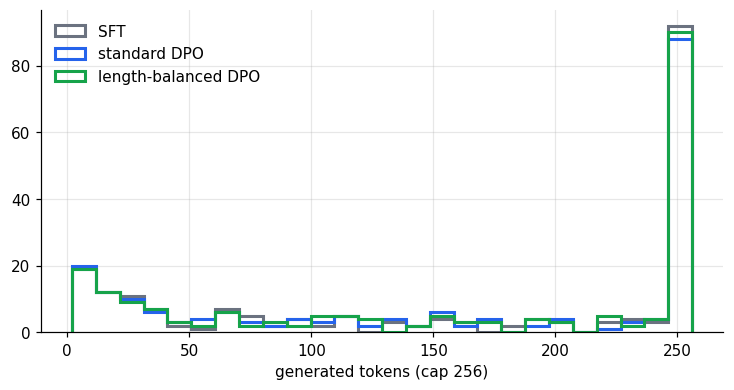

In [7]:
EV = {"SFT": load("task1_dpo/dpo_eval_sft_reference.json"), "standard DPO": load("task1_dpo/dpo_eval_standard.json"),
      "length-balanced DPO": load("task1_dpo/dpo_eval_length_balanced.json")}
display(pd.DataFrame({k: {"length mean": e["length_tokens"]["mean"], "std": e["length_tokens"]["std"], "median": e["length_tokens"]["median"],
                          "IQR": e["length_tokens"]["iqr"], "EOS rate": e["eos_rate"], "RM": e["mean_reward"], "KL token": e["kl_token_mean"]}
                      for k, e in EV.items()}).T.round(4))
fig, ax = plt.subplots(figsize=(8, 3.8))
for (k, e), c in zip(EV.items(), ["#6B7280", "#2563EB", "#16A34A"]):
    ax.hist([g["response_length_tokens"] for g in e["generations"]], bins=26, histtype="step", lw=2, color=c, label=k)
ax.set_xlabel("generated tokens (cap 256)"); ax.legend(); plt.show()

## 5. Word-limit compliance on the common prompt set

In [8]:
P = {"SFT": "sft", "standard DPO": "standard", "length-balanced DPO": "length_balanced"}
summ = {k: {"greedy compliance": LA[v]["word_limit"]["greedy_compliance_rate"],
            "greedy 95% CI": "[{:.2f}, {:.2f}]".format(*LA[v]["word_limit"]["greedy_compliance_ci95"]),
            "sampled compliance (8/prompt)": LA[v]["word_limit"]["sampled_compliance_rate"],
            "sampled 95% CI": "[{:.2f}, {:.2f}]".format(*LA[v]["word_limit"]["sampled_compliance_ci95"]),
            "greedy words mean": LA[v]["word_limit"]["greedy_word_count"]["mean"],
            "words / limit": LA[v]["word_limit"]["mean_excess_ratio"]} for k, v in P.items()}
display(pd.DataFrame(summ).T.round(3))
det = {k: LA[v]["word_limit"]["details"] for k, v in P.items()}
per = pd.DataFrame([{"prompt": d["prompt"], "limit": d["limit"], **{k: f"{det[k][i]['word_count']} {'✓' if det[k][i]['compliant'] else '✗'}" for k in det}}
                    for i, d in enumerate(det["SFT"])])
per

,greedy compliance,greedy 95% CI,sampled compliance (8/prompt),sampled 95% CI,greedy words mean,words / limit
SFT,0.5,"[0.24, 0.76]",0.4625,"[0.36, 0.57]",40.6,1.1203
standard DPO,0.4,"[0.17, 0.69]",0.4625,"[0.36, 0.57]",40.8,1.1424
length-balanced DPO,0.4,"[0.17, 0.69]",0.45,"[0.35, 0.56]",41.0,1.1373


,prompt,limit,SFT,standard DPO,length-balanced DPO
0,Explain why regularization can improve generalization in at most 40 words.,40,34 ✓,34 ✓,34 ✓
1,Define overfitting in no more than 25 words.,25,28 ✗,28 ✗,28 ✗
2,Summarize the purpose of a validation set in at most 30 words.,30,24 ✓,22 ✓,22 ✓
3,Explain gradient descent in under 35 words.,35,43 ✗,55 ✗,43 ✗
4,Describe one advantage and one limitation of attention in at most 45 words.,45,64 ✗,47 ✗,64 ✗
5,What is distribution shift? Answer in no more than 30 words.,30,22 ✓,35 ✗,35 ✗
6,Explain the role of a learning rate in at most 35 words.,35,68 ✗,65 ✗,62 ✗
7,Why can a model with high training accuracy still fail at deployment? Answer in at most 40 words.,40,34 ✓,33 ✓,33 ✓
8,Define calibration for a probabilistic classifier in under 30 words.,30,25 ✓,25 ✓,25 ✓
9,Explain what a frozen reference model does in RLHF in at most 45 words.,45,64 ✗,64 ✗,64 ✗


In [9]:
for i in [0, 3, 6]:
    d0 = det["SFT"][i]
    side_by_side(f"Word-limit prompt (limit {d0['limit']} words)", d0["prompt"], {k: det[k][i]["response"] for k in det},
                 meta={k: f"{det[k][i]['word_count']} words · {'compliant' if det[k][i]['compliant'] else 'over the limit'}" for k in det})

"SFT34 words · compliantRegularization helps prevent overfitting by adding a penalty term to the loss function that discourages large weights, thus simplifying the model and reducing its complexity. This makes the model generalize better to unseen data.","standard DPO34 words · compliantRegularization helps prevent overfitting by adding a penalty term to the loss function that discourages large weights, thus simplifying the model and reducing its complexity. This makes the model generalize better to unseen data.","length-balanced DPO34 words · compliantRegularization helps prevent overfitting by adding a penalty term to the loss function that discourages large weights, thus simplifying the model and reducing its complexity. This makes the model generalize better to unseen data."


"SFT43 words · over the limitGradient descent is an optimization algorithm used to minimize the cost function in machine learning models. It iteratively updates the model's parameters in the direction of steepest descent of the loss function, aiming to find the minimum value that minimizes prediction errors.","standard DPO55 words · over the limitGradient descent is an optimization algorithm used to minimize the cost function in machine learning models. It iteratively updates the model's parameters in the direction of steepest descent based on the negative gradient of the loss function. The goal is to find the minimum value of the cost function, leading to better model performance.","length-balanced DPO43 words · over the limitGradient descent is an optimization algorithm used to minimize the cost function in machine learning models. It iteratively updates the model's parameters in the direction of steepest descent of the loss function, aiming to find the minimum value that minimizes prediction errors."


"SFT68 words · over the limitA learning rate is a hyperparameter that determines how much to adjust the model's weights during training based on the error between predictions and targets. It controls the step size in gradient descent optimization algorithms, balancing convergence speed with risk of overshooting local minima or diverging from the optimal solution. A suitable learning rate helps ensure efficient weight updates while maintaining stability and accuracy in model training.","standard DPO65 words · over the limitA learning rate is a hyperparameter that determines how much to adjust the model's weights during training based on the error between predictions and targets. It controls the step size in gradient descent optimization algorithms, balancing convergence speed with risk of overshooting local minima or diverging from the optimal solution. A suitable learning rate helps ensure efficient weight updates while preventing overfitting or underfitting.","length-balanced DPO62 words · over the limitA learning rate determines how much to adjust the model's weights during training based on the error between predictions and targets. It controls the step size in gradient descent optimization algorithms, helping converge faster or slower depending on its value. A suitable learning rate is crucial for efficient and stable training without overshooting local minima or getting stuck in flat regions."


## 6. Qualitative: stronger preference signal, but is the response better?  (RQ3 candidates)

In [10]:
sft_g = pd.DataFrame(EV["SFT"]["generations"]); std_g = pd.DataFrame(EV["standard DPO"]["generations"])
mm = sft_g.merge(std_g, on="prompt_id", suffixes=("_sft", "_dpo")); mm = mm[mm.response_sft != mm.response_dpo]
mm["gain"] = mm.reward_score_dpo - mm.reward_score_sft
for _, r in mm.sort_values("gain", ascending=False).head(2).iterrows():
    side_by_side("Higher RM under DPO", r.prompt_sft, {"SFT": r.response_sft, "standard DPO": r.response_dpo},
                 meta={"SFT": f"RM {r.reward_score_sft:+.2f} · {r.response_length_tokens_sft} tok", "standard DPO": f"RM {r.reward_score_dpo:+.2f} · {r.response_length_tokens_dpo} tok"})

"SFTRM -0.92 · 256 tokTo modify your Ruby code to connect to an SQL database, you need to add the necessary gems for connecting to PostgreSQL, define the table structure and columns, and write a script that inserts and retrieves records from the table.Here's an example of how you could modify your code to achieve this:```rubyrequire 'pg'# Connect to the databaseconn = PG.connect(dbname: 'mydb', user: 'myuser', password: 'mypassword', host: 'localhost')# Define the table schematable_name = 'Sentences'columns = { id: Integer, sentence: String}# Insert a new record into the tablebegin # Create a new row with the updated sentence params = { sentence => new_sentence } # Insert the new record into the table conn.exec_params(""INSERT INTO #{table_name} (#{columns.keys.join(', ')}) VALUES ($1)"", [params]) puts ""New record inserted successfully""res = conn.exec(""SELECT * FROM #{table …","standard DPORM +1.49 · 256 tokTo modify your Ruby code to connect to an SQL database, you need to add the necessary gems for connecting to PostgreSQL (PG gem), and then write the appropriate code to perform the insertion and retrieval of data.Here's how you can modify the code:```rubyrequire 'pg'# Connect to the databaseconn = PG.connect(dbname: 'mydb', user: 'myuser', password: 'mypassword', host: 'localhost')begin # Insert the new sentence into the table conn.exec_params('INSERT INTO Sentences (Sentence) VALUES ($1)', [newSentence]) # Retrieve all records from the table res = conn.exec('SELECT * FROM Sentences') # Print each row with ID and Sentence res.each do |row| puts ""#{row['id']} \t #{row['sentence']}"" endensure # Close the connection conn.close unless conn.nil?end```In this modified code, we added `require 'pg'` at the top to load the Postg …"


"SFTRM -0.49 · 77 tokThe poem you're referring to is ""Bright Star"" by John Keats. It's one of the most famous poems from his collection ""Endymion."" The poem expresses deep love and longing for someone named Lorna, who appears as an object in the sky that looks like a bright star. It explores themes of mortality, beauty, and the ephemeral nature of life.","standard DPORM +1.72 · 142 tokThe poem you're referring to is ""Bright Star"" by John Keats. This sonnet was written in 1819 and is considered one of the most famous poems from Keats' short-lived career as an English Romantic poet.The poem explores themes of love, longing, and the passage of time. The speaker imagines seeing a distant object that he believes to be a bright star, but ultimately realizes that it may just be his own imagination.The poem has become iconic for its use of imagery and symbolism, particularly the idea of the moon being like a ""lamenting angel"" who watches over the speaker's beloved. It is often used in literature classes and discussions about poetry."


## 7. Evidence for RQ2 / RQ3 (facts only)

In [11]:
for mdl in ["standard", "length_balanced"]:
    st = LA[mdl]["stratified"]
    print(f"{mdl:16s} " + " | ".join(f"{s}: acc {st[s]['accuracy']:.3f}, margin {st[s]['mean_margin']:+.2f}" for s in STRATA))
print("share chosen longer: standard train %.2f, length-balanced train %.2f" % (pre["dpo_standard_train"]["chosen_minus_rejected_tokens_full"]["frac_chosen_longer"], pre["dpo_length_train"]["chosen_minus_rejected_tokens_full"]["frac_chosen_longer"]))
print("held-out generated length: " + ", ".join(f"{k} {e['length_tokens']['mean']:.1f}" for k, e in EV.items()))
print("word-limit greedy compliance: " + ", ".join(f"{k} {v['greedy compliance']:.2f}" for k, v in summ.items()))

standard         preferred_longer: acc 0.447, margin -0.08 | length_matched: acc 0.588, margin +0.20 | rejected_longer: acc 0.658, margin +0.66
length_balanced  preferred_longer: acc 0.434, margin -0.49 | length_matched: acc 0.613, margin +0.34 | rejected_longer: acc 0.785, margin +1.43
share chosen longer: standard train 0.57, length-balanced train 0.49
held-out generated length: SFT 162.6, standard DPO 158.8, length-balanced DPO 162.8
word-limit greedy compliance: SFT 0.50, standard DPO 0.40, length-balanced DPO 0.40
